In [ ]:
import os
import itertools
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd

import cartopy.crs as ccrs
import cartopy.feature as cf

from matplotlib import patches
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import FancyArrowPatch

from shapely.geometry import Point

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append(os.path.abspath(".."))
from function import ART_preprocessing as ART_pre

In [2]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','5_DOWN')

In [239]:
DATA = xr.open_dataset(os.path.join(dir_base,'ITALY_DOWN_ERA5_3h_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc'))

lons = DATA.lon.values
lats = DATA.lat.values
lon2d, lat2d = np.meshgrid(lons, lats)

NYs = DATA.NYs.values
CYs = DATA.CYs.values
WYs = DATA.WYs.values

BETA = DATA.BETA.values
GAMMA = DATA.GAMMA.values

Mev_s = DATA.Mev_s.values[3,:,:]
Mev_d = DATA.Mev_d.values[3,:,:]

In [5]:
# lon_min, lon_max, lat_min, lat_max = 10.5, 13.5, 44.5, 47
lon_min, lon_max, lat_min, lat_max, area, toll = 6.5, 19, 36.5, 48, 'ITALY', 0.002

veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

if os.path.exists(veneto_dir):
    REGIONS = gpd.read_file(os.path.join(veneto_dir,'Italy_regions.geojson'))
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

italy_geom = ITALY.union_all()

In [263]:
NYs_levels = np.arange(30, 275, 5)
NYs_cmap = plt.cm.viridis
NYs_norm = BoundaryNorm(NYs_levels, ncolors=NYs_cmap.N, clip=True)

CYs_levels = np.arange(1, 20.5, 0.5)
CYs_cmap = plt.cm.viridis
CYs_norm = BoundaryNorm(CYs_levels, ncolors=CYs_cmap.N, clip=True)

WYs_levels = np.arange(0.4, 1.25, 0.05)
WYs_cmap = plt.cm.viridis
WYs_norm = BoundaryNorm(WYs_levels, ncolors=WYs_cmap.N, clip=True)

BETA_levels = np.arange(0.7, 1.35, 0.05)
BETA_cmap = plt.cm.Blues
BETA_norm = BoundaryNorm(BETA_levels, ncolors=BETA_cmap.N, clip=True)

GAMMA_levels = np.arange(0.87, 0.98, 0.01)
GAMMA_cmap = plt.cm.Reds
GAMMA_norm = BoundaryNorm(GAMMA_levels, ncolors=GAMMA_cmap.N, clip=True)

Mev_levels = np.arange(40, 325, 5)
Mev_cmap = plt.cm.Spectral_r
Mev_norm = BoundaryNorm(Mev_levels, ncolors=Mev_cmap.N, clip=True)

cmap_bin = plt.get_cmap('viridis', 3) 
norm = mcolors.BoundaryNorm([0, 0.5, 1], cmap_bin.N)  

In [291]:
lats_in, lons_in = [], []
for i in range(len(lats)):
    for j in range(len(lons)):

        lat_c = lats[i]
        lon_c = lons[j]

        point = Point(lon_c, lat_c)
        is_inside = ITALY.contains(point).any()
        
        if is_inside == True:
            lats_in.append(lat_c)
            lons_in.append(lon_c)

## Test for points

In [292]:
NYs_tmp = np.zeros([len(lats),len(lons)])*np.nan
CYs_tmp = np.zeros([len(lats),len(lons)])*np.nan
WYs_tmp = np.zeros([len(lats),len(lons)])*np.nan

BETA_tmp = np.zeros([len(lats),len(lons)])*np.nan
GAMMA_tmp = np.zeros([len(lats),len(lons)])*np.nan 

MEVs_tmp = np.zeros([len(lats),len(lons)])*np.nan
MEVd_tmp = np.zeros([len(lats),len(lons)])*np.nan

for i in range(len(lats_in)):

    lat_c = lats_in[i]
    lon_c = lons_in[i]

    lat_index = np.where(lats==lat_c)[0][0]
    lon_index = np.where(lons==lon_c)[0][0]

    NYs_tmp[lat_index,lon_index] = np.nanmean(NYs[:,lat_index,lon_index])
    CYs_tmp[lat_index,lon_index] = np.nanmean(CYs[:,lat_index,lon_index])
    WYs_tmp[lat_index,lon_index] = np.nanmean(WYs[:,lat_index,lon_index])

    BETA_tmp[lat_index,lon_index] = BETA[lat_index,lon_index]
    GAMMA_tmp[lat_index,lon_index] = GAMMA[lat_index,lon_index]

    MEVs_tmp[lat_index,lon_index] = Mev_s[lat_index,lon_index]
    MEVd_tmp[lat_index,lon_index] = Mev_d[lat_index,lon_index]

    BOX = ART_pre.create_box_v2(DATA, lat_c, lon_c, 2)
    lat_box = BOX['lat'].data
    lon_box = BOX['lon'].data
    box_lon2d, box_lat2d = np.meshgrid(lon_box, lat_box)

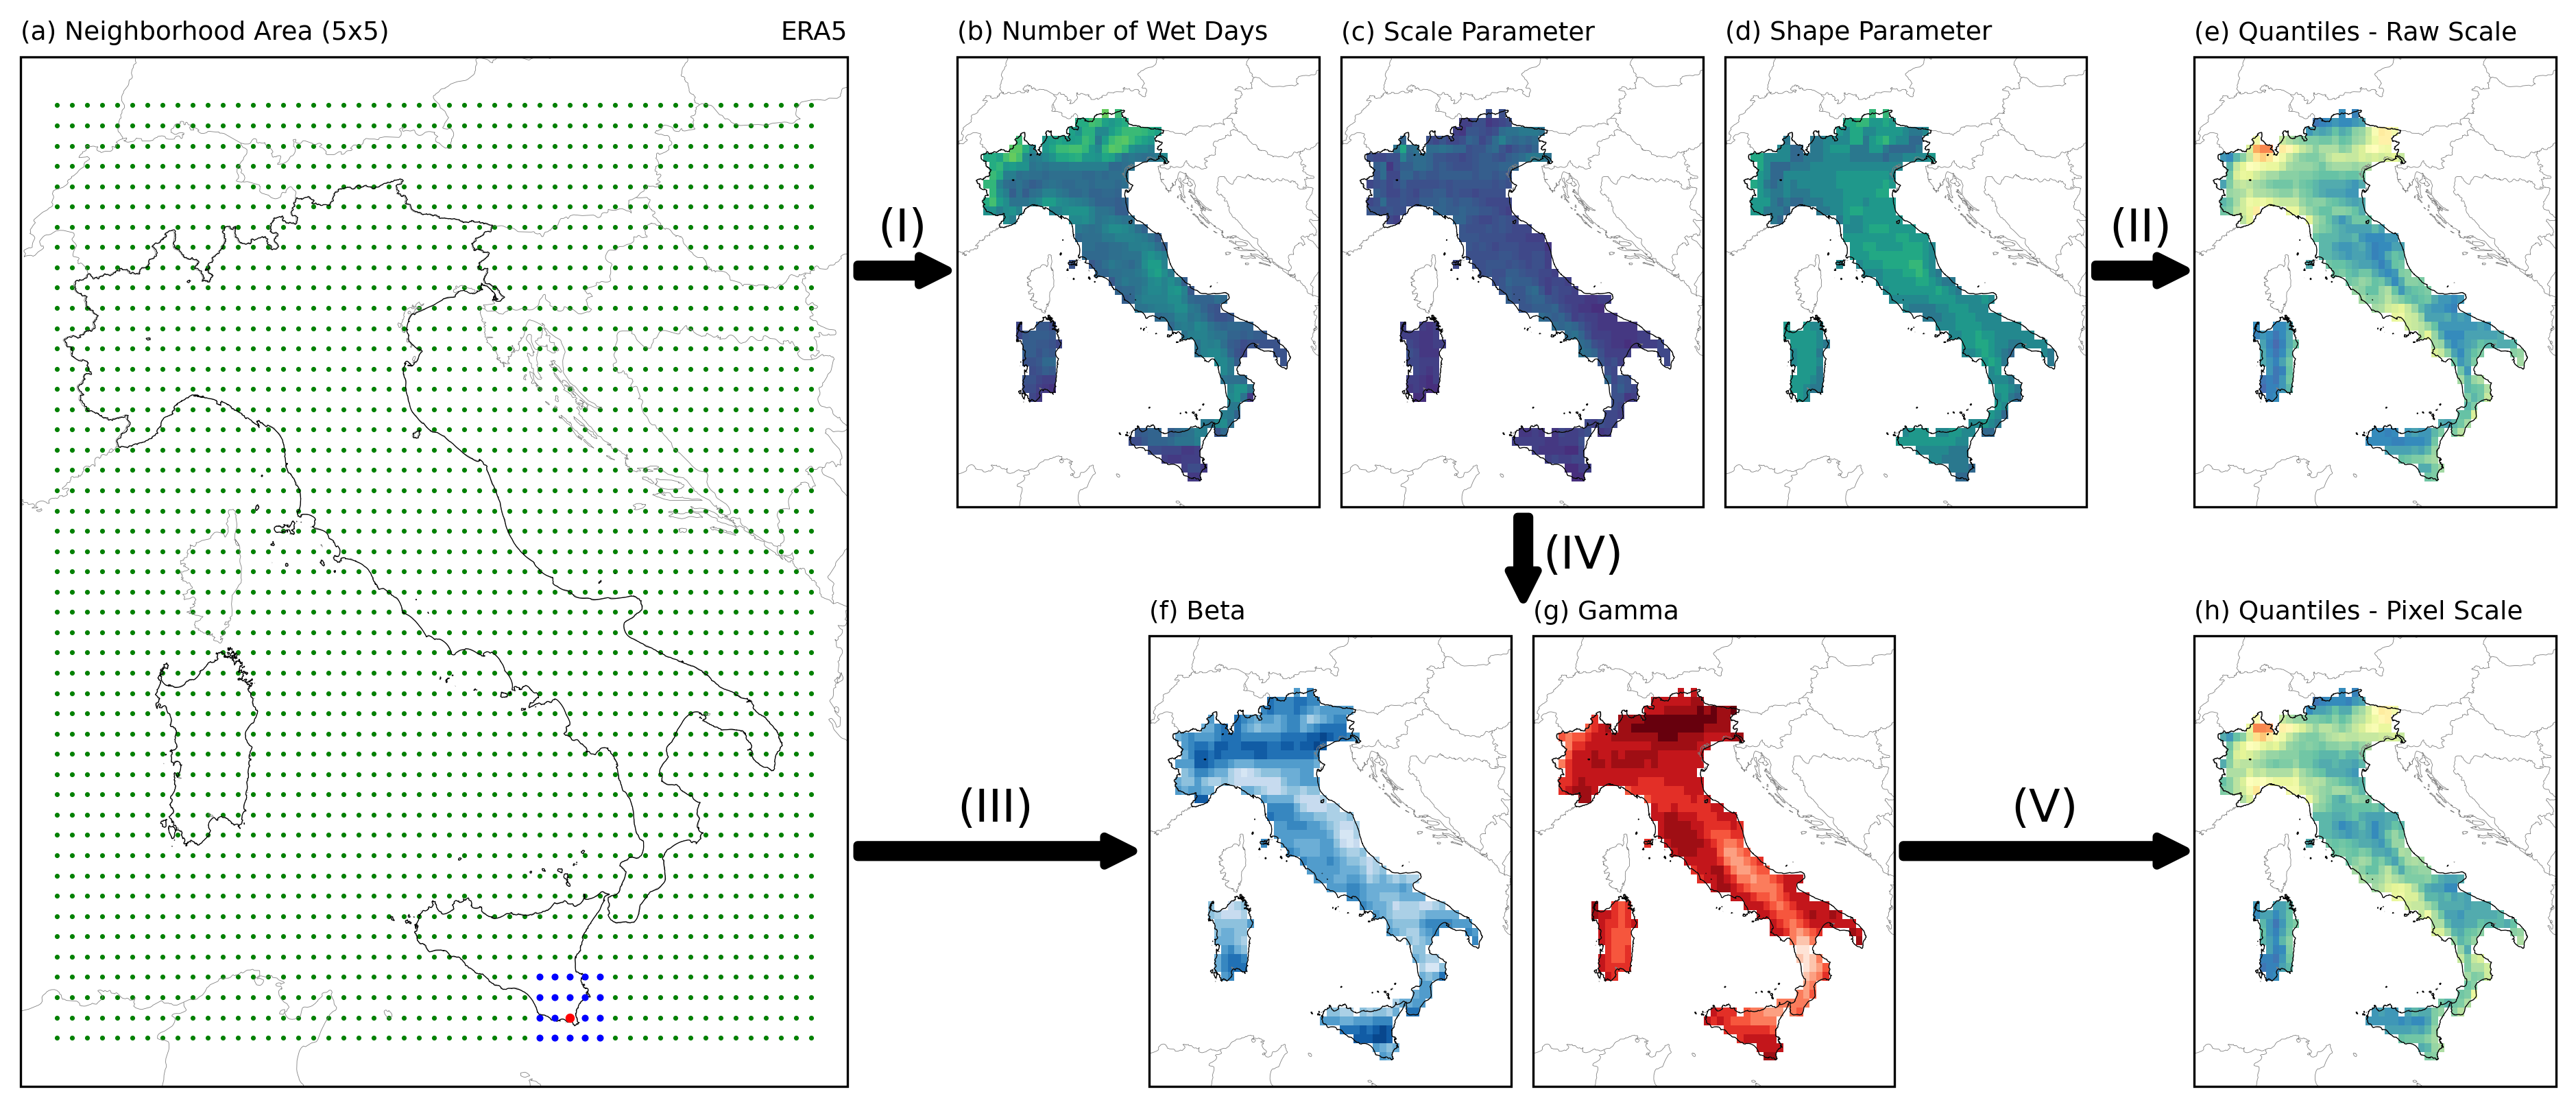

In [293]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(17,6.5),dpi=300)
gs = gridspec.GridSpec(4,12,width_ratios=[1,1,1,2.5,1,1,1,1,1,1,2,1])

# ============================================================================================================================
ax_neigh = plt.subplot(gs[0:, 0:4], projection = proj)
ax_neigh.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax_neigh.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax_neigh.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax_neigh, zorder=10)

ax_neigh.scatter(lon2d, lat2d, s=0.5, c='g', marker='o', label='Study pixels')
ax_neigh.scatter(box_lon2d, box_lat2d, s=2, c='b', label='Box pixels', zorder=50)
ax_neigh.scatter(lon_c, lat_c, s=5 , c='r', label='Central pixel', zorder=55)

ax_neigh.set_title('(a) Neighborhood Area (5x5)', loc='left', fontsize=9)
ax_neigh.set_title('ERA5', loc='right', fontsize=9)

# ============================================================================================================================
ax1 = plt.subplot(gs[0:2, 4:6], projection = proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

a1 = ax1.pcolormesh(lon2d, lat2d, NYs_tmp, cmap=NYs_cmap, norm=NYs_norm)

ax1.set_title('(b) Number of Wet Days', loc='left', fontsize=9)

# ============================================================================================================================
ax1 = plt.subplot(gs[0:2, 6:8], projection = proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

a1 = ax1.pcolormesh(lon2d, lat2d, CYs_tmp, cmap=CYs_cmap, norm=CYs_norm)

ax1.set_title('(c) Scale Parameter', loc='left', fontsize=9)

# ============================================================================================================================
ax1 = plt.subplot(gs[0:2, 8:10], projection = proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

a1 = ax1.pcolormesh(lon2d, lat2d, WYs_tmp, cmap=WYs_cmap, norm=WYs_norm)

ax1.set_title('(d) Shape Parameter', loc='left', fontsize=9)

# ============================================================================================================================
ax1 = plt.subplot(gs[0:2, 10:], projection = proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

a1 = ax1.pcolormesh(lon2d, lat2d, MEVs_tmp, cmap=Mev_cmap, norm=Mev_norm)

ax1.set_title('(e) Quantiles - Raw Scale', loc='left', fontsize=9)

# ============================================================================================================================
ax_beta = plt.subplot(gs[2:, 5:7], projection = proj)
ax_beta.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax_beta.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax_beta.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax_beta, zorder=10)

a1 = ax_beta.pcolormesh(lon2d, lat2d, BETA_tmp, cmap=BETA_cmap, norm=BETA_norm)

ax_beta.set_title('(f) Beta', loc='left', fontsize=9)

# ============================================================================================================================
ax1 = plt.subplot(gs[2:, 7:9], projection = proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

a1 = ax1.pcolormesh(lon2d, lat2d, GAMMA_tmp, cmap=GAMMA_cmap, norm=GAMMA_norm)

ax1.set_title('(g) Gamma', loc='left', fontsize=9)

# ============================================================================================================================
ax1 = plt.subplot(gs[2:, 10:], projection = proj)
ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

a1 = ax1.pcolormesh(lon2d, lat2d, MEVd_tmp, cmap=Mev_cmap, norm=Mev_norm)

ax1.set_title('(h) Quantiles - Pixel Scale', loc='left', fontsize=9)


# ============================================================================================================================
start = 0.388, 0.72
end = 0.417, 0.72
x_mid = (start[0] + end[0]) / 2
y_mid = (start[1] + end[1]) / 2
arrow1 = FancyArrowPatch(
    start,
    end,
    transform=fig.transFigure,
    arrowstyle='simple',
    mutation_scale=20,
    linewidth=3,
    color='black'
)
fig.text(
    x_mid,
    y_mid + 0.015,   # controla la altura
    '(I)',
    ha='center',
    va='bottom',
    fontsize=16,
    # fontweight='bold'
)

start = 0.742, 0.72
end = 0.771, 0.72
x_mid = (start[0] + end[0]) / 2
y_mid = (start[1] + end[1]) / 2
arrow11 = FancyArrowPatch(
    start,
    end,
    transform=fig.transFigure,
    arrowstyle='simple',
    mutation_scale=20,
    linewidth=3,
    color='black'
)
fig.text(
    x_mid,
    y_mid + 0.015,   # controla la altura
    '(II)',
    ha='center',
    va='bottom',
    fontsize=16,
    # fontweight='bold'
)

start = 0.388, 0.286
end = 0.47, 0.286
x_mid = (start[0] + end[0]) / 2
y_mid = (start[1] + end[1]) / 2
arrow2 = FancyArrowPatch(
    start,
    end,
    transform=fig.transFigure,
    arrowstyle='simple',
    mutation_scale=20,
    linewidth=3,
    color='black'
)
fig.text(
    x_mid,
    y_mid + 0.015,   # controla la altura
    '(III)',
    ha='center',
    va='bottom',
    fontsize=16,
    # fontweight='bold'
)

start = 0.687, 0.286
end = 0.771, 0.286
x_mid = (start[0] + end[0]) / 2
y_mid = (start[1] + end[1]) / 2
arrow21 = FancyArrowPatch(
    start,
    end,
    transform=fig.transFigure,
    arrowstyle='simple',
    mutation_scale=20,
    linewidth=3,
    color='black'
)
fig.text(
    x_mid,
    y_mid + 0.015,   # controla la altura
    '(V)',
    ha='center',
    va='bottom',
    fontsize=16,
    # fontweight='bold'
)

start = 0.58, 0.54
end = 0.58, 0.47
x_mid = (start[0] + end[0]) / 2
y_mid = (start[1] + end[1]) / 2
arrow22 = FancyArrowPatch(
    start,
    end,
    transform=fig.transFigure,
    arrowstyle='simple',
    mutation_scale=20,
    linewidth=3,
    color='black'
)
fig.text(
    x_mid + 0.017,
    y_mid - 0.015,   # controla la altura
    '(IV)',
    ha='center',
    va='bottom',
    fontsize=16,
    # fontweight='bold'
)

arrow1.set_zorder(1000)
fig.add_artist(arrow1)

arrow11.set_zorder(1000)
fig.add_artist(arrow11)

arrow2.set_zorder(1000)
fig.add_artist(arrow2)

arrow21.set_zorder(1000)
fig.add_artist(arrow21)

arrow22.set_zorder(1000)
fig.add_artist(arrow22)

# ============================================================================================================================
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, hspace=0.8, wspace=0.1)

In [274]:
sys.exit()

SystemExit: 

## Create giff

In [290]:
NYs_tmp = np.zeros([len(lats),len(lons)])*np.nan
CYs_tmp = np.zeros([len(lats),len(lons)])*np.nan
WYs_tmp = np.zeros([len(lats),len(lons)])*np.nan

BETA_tmp = np.zeros([len(lats),len(lons)])*np.nan
GAMMA_tmp = np.zeros([len(lats),len(lons)])*np.nan 

MEVs_tmp = np.zeros([len(lats),len(lons)])*np.nan
MEVd_tmp = np.zeros([len(lats),len(lons)])*np.nan

nn = 0
for i in range(len(lats_in)):

    lat_c = lats_in[i]
    lon_c = lons_in[i]

    lat_index = np.where(lats==lat_c)[0][0]
    lon_index = np.where(lons==lon_c)[0][0]

    NYs_tmp[lat_index,lon_index] = np.nanmean(NYs[:,lat_index,lon_index])
    CYs_tmp[lat_index,lon_index] = np.nanmean(CYs[:,lat_index,lon_index])
    WYs_tmp[lat_index,lon_index] = np.nanmean(WYs[:,lat_index,lon_index])

    BETA_tmp[lat_index,lon_index] = BETA[lat_index,lon_index]
    GAMMA_tmp[lat_index,lon_index] = GAMMA[lat_index,lon_index]

    MEVs_tmp[lat_index,lon_index] = Mev_s[lat_index,lon_index]
    MEVd_tmp[lat_index,lon_index] = Mev_d[lat_index,lon_index]

    BOX = ART_pre.create_box_v2(DATA, lat_c, lon_c, 2)
    lat_box = BOX['lat'].data
    lon_box = BOX['lon'].data
    box_lon2d, box_lat2d = np.meshgrid(lon_box, lat_box)

    fig = plt.figure(figsize=(17,6.5),dpi=300)
    gs = gridspec.GridSpec(4,12,width_ratios=[1,1,1,2.5,1,1,1,1,1,1,2,1])

    # ============================================================================================================================
    ax_neigh = plt.subplot(gs[0:, 0:4], projection = proj)
    ax_neigh.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
    ax_neigh.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
    ax_neigh.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
    im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax_neigh, zorder=10)

    ax_neigh.scatter(lon2d, lat2d, s=0.5, c='g', marker='o', label='Study pixels')
    ax_neigh.scatter(box_lon2d, box_lat2d, s=2, c='b', label='Box pixels', zorder=50)
    ax_neigh.scatter(lon_c, lat_c, s=5 , c='r', label='Central pixel', zorder=55)

    ax_neigh.set_title('(a) Neighborhood Area (5x5)', loc='left', fontsize=9)
    ax_neigh.set_title('ERA5', loc='right', fontsize=9)

    # ============================================================================================================================
    ax1 = plt.subplot(gs[0:2, 4:6], projection = proj)
    ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
    ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
    ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
    im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

    a1 = ax1.pcolormesh(lon2d, lat2d, NYs_tmp, cmap=NYs_cmap, norm=NYs_norm)

    ax1.set_title('(b) Number of Wet Days', loc='left', fontsize=9)

    # ============================================================================================================================
    ax1 = plt.subplot(gs[0:2, 6:8], projection = proj)
    ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
    ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
    ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
    im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

    a1 = ax1.pcolormesh(lon2d, lat2d, CYs_tmp, cmap=CYs_cmap, norm=CYs_norm)

    ax1.set_title('(c) Scale Parameter', loc='left', fontsize=9)

    # ============================================================================================================================
    ax1 = plt.subplot(gs[0:2, 8:10], projection = proj)
    ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
    ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
    ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
    im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

    a1 = ax1.pcolormesh(lon2d, lat2d, WYs_tmp, cmap=WYs_cmap, norm=WYs_norm)

    ax1.set_title('(d) Shape Parameter', loc='left', fontsize=9)

    # ============================================================================================================================
    ax1 = plt.subplot(gs[0:2, 10:], projection = proj)
    ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
    ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
    ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
    im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

    a1 = ax1.pcolormesh(lon2d, lat2d, MEVs_tmp, cmap=Mev_cmap, norm=Mev_norm)

    ax1.set_title('(e) Quantiles - Raw Scale', loc='left', fontsize=9)

    # ============================================================================================================================
    ax_beta = plt.subplot(gs[2:, 5:7], projection = proj)
    ax_beta.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
    ax_beta.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
    ax_beta.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
    im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax_beta, zorder=10)

    a1 = ax_beta.pcolormesh(lon2d, lat2d, BETA_tmp, cmap=BETA_cmap, norm=BETA_norm)

    ax_beta.set_title('(f) Beta', loc='left', fontsize=9)

    # ============================================================================================================================
    ax1 = plt.subplot(gs[2:, 7:9], projection = proj)
    ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
    ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
    ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
    im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

    a1 = ax1.pcolormesh(lon2d, lat2d, GAMMA_tmp, cmap=GAMMA_cmap, norm=GAMMA_norm)

    ax1.set_title('(g) Gamma', loc='left', fontsize=9)

    # ============================================================================================================================
    ax1 = plt.subplot(gs[2:, 10:], projection = proj)
    ax1.set_extent([lon_min-0.6, lon_max+0.6, lat_min-0.6, lat_max+0.6],crs=proj)
    ax1.add_feature(cf.COASTLINE,linewidth=0.2,color='grey')
    ax1.add_feature(cf.BORDERS,linewidth=0.2,color='grey')
    im = ITALY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.3, ax=ax1, zorder=10)

    a1 = ax1.pcolormesh(lon2d, lat2d, MEVd_tmp, cmap=Mev_cmap, norm=Mev_norm)

    ax1.set_title('(h) Quantiles - Pixel Scale', loc='left', fontsize=9)


    # ============================================================================================================================
    start = 0.388, 0.72
    end = 0.417, 0.72
    x_mid = (start[0] + end[0]) / 2
    y_mid = (start[1] + end[1]) / 2
    arrow1 = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        arrowstyle='simple',
        mutation_scale=20,
        linewidth=3,
        color='black'
    )
    fig.text(
        x_mid,
        y_mid + 0.015,   # controla la altura
        '(I)',
        ha='center',
        va='bottom',
        fontsize=16,
        # fontweight='bold'
    )

    start = 0.742, 0.72
    end = 0.771, 0.72
    x_mid = (start[0] + end[0]) / 2
    y_mid = (start[1] + end[1]) / 2
    arrow11 = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        arrowstyle='simple',
        mutation_scale=20,
        linewidth=3,
        color='black'
    )
    fig.text(
        x_mid,
        y_mid + 0.015,   # controla la altura
        '(II)',
        ha='center',
        va='bottom',
        fontsize=16,
        # fontweight='bold'
    )

    start = 0.388, 0.286
    end = 0.47, 0.286
    x_mid = (start[0] + end[0]) / 2
    y_mid = (start[1] + end[1]) / 2
    arrow2 = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        arrowstyle='simple',
        mutation_scale=20,
        linewidth=3,
        color='black'
    )
    fig.text(
        x_mid,
        y_mid + 0.015,   # controla la altura
        '(III)',
        ha='center',
        va='bottom',
        fontsize=16,
        # fontweight='bold'
    )

    start = 0.687, 0.286
    end = 0.771, 0.286
    x_mid = (start[0] + end[0]) / 2
    y_mid = (start[1] + end[1]) / 2
    arrow21 = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        arrowstyle='simple',
        mutation_scale=20,
        linewidth=3,
        color='black'
    )
    fig.text(
        x_mid,
        y_mid + 0.015,   # controla la altura
        '(V)',
        ha='center',
        va='bottom',
        fontsize=16,
        # fontweight='bold'
    )

    start = 0.58, 0.54
    end = 0.58, 0.47
    x_mid = (start[0] + end[0]) / 2
    y_mid = (start[1] + end[1]) / 2
    arrow22 = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        arrowstyle='simple',
        mutation_scale=20,
        linewidth=3,
        color='black'
    )
    fig.text(
        x_mid + 0.017,
        y_mid - 0.015,   # controla la altura
        '(IV)',
        ha='center',
        va='bottom',
        fontsize=16,
        # fontweight='bold'
    )

    arrow1.set_zorder(1000)
    fig.add_artist(arrow1)

    arrow11.set_zorder(1000)
    fig.add_artist(arrow11)

    arrow2.set_zorder(1000)
    fig.add_artist(arrow2)

    arrow21.set_zorder(1000)
    fig.add_artist(arrow21)

    arrow22.set_zorder(1000)
    fig.add_artist(arrow22)

    # ============================================================================================================================
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, hspace=0.8, wspace=0.1)

    salida = os.path.join('..','fig','gif','ITALY',f'IT_{str(nn).zfill(5)}.png')
    print(f'Export figure to: {salida}')
    plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)

    nn += 1

    plt.close()

Export figure to: ../fig/gif/ITALY/IT_00000.png
Export figure to: ../fig/gif/ITALY/IT_00001.png
Export figure to: ../fig/gif/ITALY/IT_00002.png
Export figure to: ../fig/gif/ITALY/IT_00003.png
Export figure to: ../fig/gif/ITALY/IT_00004.png
Export figure to: ../fig/gif/ITALY/IT_00005.png
Export figure to: ../fig/gif/ITALY/IT_00006.png
Export figure to: ../fig/gif/ITALY/IT_00007.png
Export figure to: ../fig/gif/ITALY/IT_00008.png
Export figure to: ../fig/gif/ITALY/IT_00009.png
Export figure to: ../fig/gif/ITALY/IT_00010.png
Export figure to: ../fig/gif/ITALY/IT_00011.png
Export figure to: ../fig/gif/ITALY/IT_00012.png
Export figure to: ../fig/gif/ITALY/IT_00013.png
Export figure to: ../fig/gif/ITALY/IT_00014.png
Export figure to: ../fig/gif/ITALY/IT_00015.png
Export figure to: ../fig/gif/ITALY/IT_00016.png
Export figure to: ../fig/gif/ITALY/IT_00017.png
Export figure to: ../fig/gif/ITALY/IT_00018.png
Export figure to: ../fig/gif/ITALY/IT_00019.png
Export figure to: ../fig/gif/ITALY/IT_00